# **MARYAM KHAN**
# **AI/ML Internship**
# **Task 03 – End-to-End Machine Learning Project Objective**
## **Part 1 – Data Preparation**
### Import dataset

In [4]:
import pandas as pd

df = pd.read_csv("../dataset/Telco _Customer_Churn.csv")

In [5]:
print(df.head(5))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [6]:
print("Shape", df.shape)

Shape (7043, 21)


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Handle missing values


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing after fill:", df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

Missing TotalCharges after conversion: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN
Missing after fill: 0
float64


We convert TotalCharges to numeric using pd.to_numeric(..., errors='coerce'). Any value that can't convert (like blank spaces) becomes NaN, which isnull() will now catch. These blanks belong to customers with tenure = 0 (brand new customers who haven't been charged yet), so we fill them with 0 instead of dropping the rows.

### Remove duplicates

In [10]:
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows before: 0
Shape after removing duplicates: (7043, 21)


We removed duplicates rows but no duplicate rows were found there

### Feature Engineering

In [ ]:
# Drop identifier column 
df = df.drop(columns=['customerID'])

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Feature 1: Total number of subscribed services
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_services(row):
    return sum(1 for col in service_cols if row[col] == 'Yes')

df['TotalServices'] = df.apply(count_services, axis=1)

# Feature 2: Average monthly spend 
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

print(df[['TotalServices', 'AvgMonthlySpend', 'Churn']].head())
print(df.shape)
print(df['Churn'].value_counts())

   TotalServices  AvgMonthlySpend  Churn
0              1        29.850000      0
1              3        55.573529      0
2              3        54.075000      1
3              3        40.905556      0
4              1        75.825000      1
(7043, 22)
Churn
0    5174
1    1869
Name: count, dtype: int64


This step creates and prepares features the model can actually learn from:

- Drop customerID — it's just a unique identifier with no predictive signal, keeping it could confuse the model or cause leakage.
- Encode the target Churn — convert Yes/No into 1/0 since ML models need numeric targets.
- Create TotalServices — a count of how many add-on services (like OnlineSecurity, TechSupport, StreamingTV, etc.) each customer subscribes to. Customers with more services often behave differently regarding churn.
- Create AvgMonthlySpend — TotalCharges / tenure, giving a normalized sense of spending per month over the customer's lifetime (useful since TotalCharges alone is biased by how long someone's been a customer).

### Feature Selection

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)

# Correlation with target
corr = df_encoded.corr()['Churn'].sort_values(ascending=False)
print("Top correlated features with Churn:\n", corr.head(5))
print("\nLeast correlated features with Churn:\n", corr.tail(5))

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 33)
Top correlated features with Churn:
 Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
AvgMonthlySpend                   0.193301
Name: Churn, dtype: float64

Least correlated features with Churn:
 DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn, dtype: float64


C:\Users\maryam gull\AppData\Local\Temp\ipykernel_14864\1633827396.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


ML models need numeric input, but many of our columns are still categorical text (gender, Contract, PaymentMethod, etc.). We:

- One-hot encode all categorical columns — turns each category into its own 0/1 column (drop_first=True avoids redundant columns/multicollinearity).
- Check correlation with the target — a quick sanity check to see which features look most related to churn, before we move to modeling. We aren't dropping anything yet, just inspecting.

### Data Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AvgMonthlySpend']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print(df_encoded[numeric_cols].describe())
print(df_encoded.shape)
# saving data for part2
df_encoded.to_csv("telco_processed.csv", index=False)
print("Saved telco_processed.csv")

             tenure  MonthlyCharges  TotalCharges  TotalServices  \
count  7.043000e+03    7.043000e+03  7.043000e+03   7.043000e+03   
mean  -2.421273e-17   -6.406285e-17 -3.783239e-17  -5.044319e-17   
std    1.000071e+00    1.000071e+00  1.000071e+00   1.000071e+00   
min   -1.318165e+00   -1.545860e+00 -1.005780e+00  -1.630990e+00   
25%   -9.516817e-01   -9.725399e-01 -8.299464e-01  -1.145997e+00   
50%   -1.372744e-01    1.857327e-01 -3.905282e-01  -1.760106e-01   
75%    9.214551e-01    8.338335e-01  6.648034e-01   7.939757e-01   
max    1.613701e+00    1.794352e+00  2.825806e+00   2.248955e+00   

       AvgMonthlySpend  
count     7.043000e+03  
mean      7.465592e-17  
std       1.000071e+00  
min      -2.137475e+00  
25%      -9.597171e-01  
50%       1.850696e-01  
75%       8.416645e-01  
max       1.873292e+00  
(7043, 33)
Saved telco_processed.csv


Numeric columns like tenure, MonthlyCharges, TotalCharges are on very different scales (e.g., tenure 0–72 vs TotalCharges 0–8000+). Models like SVM and gradient-based ones are sensitive to this and can be biased toward large-magnitude features. We use StandardScaler to transform numeric columns to mean 0, standard deviation 1. (Tree-based models like Random Forest don't strictly need this, but it doesn't hurt them and keeps the pipeline consistent across all models.)

## **Part 2 – Model Development**
### Train-test split

In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (5634, 32)
X_test shape: (1409, 32)
y_train distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


We separate features (X) from the target (Churn), then split into training and testing sets. We use stratify=y because we found the target is imbalanced (73% vs 27%) — this ensures both train and test sets keep the same churn ratio. We'll use an 80/20 split with a fixed random_state so results are reproducible.

### Model 1: Decision Tree



In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7416607523066004

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82      1035
           1       0.51      0.52      0.52       374

    accuracy                           0.74      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.74      0.74      1409

Confusion Matrix:
 [[849 186]
 [178 196]]


A Decision Tree splits data on feature thresholds to form a tree of decisions. It's simple, interpretable, and a good baseline — but prone to overfitting on its own (which is why Random Forest/Gradient Boosting exist as improvements). We train it, predict on the test set, and evaluate with accuracy, precision, recall, F1, and a confusion matrix (accuracy alone is misleading on imbalanced data).

### Model 2: Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7679205110007097

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

Confusion Matrix:
 [[844 191]
 [136 238]]


Random Forest builds many decision trees on random subsets of data/features and averages their predictions. This reduces overfitting and variance compared to a single Decision Tree, usually giving better generalization. We also set class_weight='balanced' to give more weight to the minority class (churners) during training, since our data is imbalanced.

### Model 3: Support Vector Machine (SVM)

In [17]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42, class_weight='balanced')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.7501774308019872

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

Confusion Matrix:
 [[764 271]
 [ 81 293]]


SVM finds the optimal boundary (hyperplane) that separates classes with maximum margin. It works well on scaled data (which we already did in Part 1) and can capture non-linear patterns using kernels (we'll use the default rbf kernel). Like Random Forest, we set class_weight='balanced' to handle the imbalance.

### Model 4: Gradient Boosting

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

gb_model = GradientBoostingClassifier(random_state=42)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7459190915542938

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

Confusion Matrix:
 [[747 288]
 [ 70 304]]


Gradient Boosting builds trees sequentially, where each new tree corrects the errors of the previous ones. It often achieves strong accuracy on tabular data like this. Unlike Random Forest/SVM, sklearn's GradientBoostingClassifier doesn't have a class_weight parameter, so we handle imbalance differently — by passing sample_weight during fit, computed from class frequencies.

## **Part 3 – Model Optimization**
### Cross Validation (baseline, before tuning)

In [19]:
from sklearn.model_selection import cross_val_score

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name}: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")

Decision Tree: Mean F1 = 0.5048, Std = 0.0046
Random Forest: Mean F1 = 0.6092, Std = 0.0179
SVM: Mean F1 = 0.6195, Std = 0.0201
Gradient Boosting: Mean F1 = 0.5754, Std = 0.0377


Before tuning, let's check how stable each model's performance is using 5-fold cross-validation on the training set. This gives a more reliable estimate than a single train/test split, since it averages performance across 5 different splits of the data. We'll use f1 as the scoring metric (not accuracy) since we care about catching churners on imbalanced data.

### Hyperparameter Tuning
#### Decision Tree Tuning

In [20]:
from sklearn.model_selection import GridSearchCV

# Decision Tree
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print("Decision Tree best params:", dt_grid.best_params_)
print("Decision Tree best F1:", dt_grid.best_score_)

Decision Tree best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Decision Tree best F1: 0.5334052620907104


We'll use GridSearchCV to systematically try combinations of hyperparameters and pick the best one per model, using 5-fold CV and f1 scoring (same metric as above, for consistency). We'll tune all 4 models. This step can take a few minutes to run, especially SVM and Gradient Boosting — that's expected, don't worry if it's slow.



#### Random Forest tuning

In [21]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_params, cv=5, scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Random Forest best params:", rf_grid.best_params_)
print("Random Forest best F1:", rf_grid.best_score_)

Random Forest best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest best F1: 0.634084345041378


Same GridSearchCV approach, now tuning Random Forest's key parameters: number of trees (n_estimators), tree depth, and split/leaf sizes. We keep class_weight='balanced' fixed since we know the data is imbalanced.

#### SVM Tuning

In [22]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(
    SVC(random_state=42, class_weight='balanced'),
    svm_params, cv=5, scoring='f1', n_jobs=-1
)
svm_grid.fit(X_train, y_train)
print("SVM best params:", svm_grid.best_params_)
print("SVM best F1:", svm_grid.best_score_)

SVM best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM best F1: 0.6258361018613793


For SVM, the key hyperparameters are C (regularization strength — trade-off between margin size and misclassification), kernel (shape of decision boundary), and gamma (how far the influence of a single point reaches, for non-linear kernels). This grid is a bit heavier computationally, so it may take a few minutes.

#### Gradient Boosting Tuning

In [23]:
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=5, scoring='f1', n_jobs=-1
)
gb_grid.fit(X_train, y_train, sample_weight=sample_weights)
print("Gradient Boosting best params:", gb_grid.best_params_)
print("Gradient Boosting best F1:", gb_grid.best_score_)

Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Gradient Boosting best F1: 0.7782958503178032


For Gradient Boosting, we tune n_estimators (number of boosting stages), learning_rate (how much each tree corrects the previous one — lower is more conservative), and max_depth (complexity per tree). Since GradientBoostingClassifier doesn't support class_weight, we pass sample_weight inside fit() via GridSearchCV's fit_params equivalent — done using .fit(X_train, y_train, sample_weight=...).

### Feature Importance Analysis.

In [24]:
dt_best = dt_grid.best_estimator_
rf_best = rf_grid.best_estimator_
svm_best = svm_grid.best_estimator_
gb_best = gb_grid.best_estimator_

In [25]:
import pandas as pd

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_best.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 15 Random Forest Feature Importances:")
print(importances.head(15))

Top 15 Random Forest Feature Importances:
                               feature  importance
1                               tenure    0.154902
3                         TotalCharges    0.134718
27                   Contract_Two year    0.087576
5                      AvgMonthlySpend    0.077668
2                       MonthlyCharges    0.077077
12         InternetService_Fiber optic    0.072418
30      PaymentMethod_Electronic check    0.052949
26                   Contract_One year    0.035232
15                  OnlineSecurity_Yes    0.028918
4                        TotalServices    0.027692
21                     TechSupport_Yes    0.023568
13                  InternetService_No    0.019264
28                PaperlessBilling_Yes    0.017481
16    OnlineBackup_No internet service    0.015761
14  OnlineSecurity_No internet service    0.015157


We'll extract feature importances from our tree-based models (Decision Tree, Random Forest, Gradient Boosting all support this natively via .feature_importances_). SVM doesn't have a direct equivalent since it's not tree-based, so we'll focus on the tree models here — this tells us which features actually drive churn predictions.

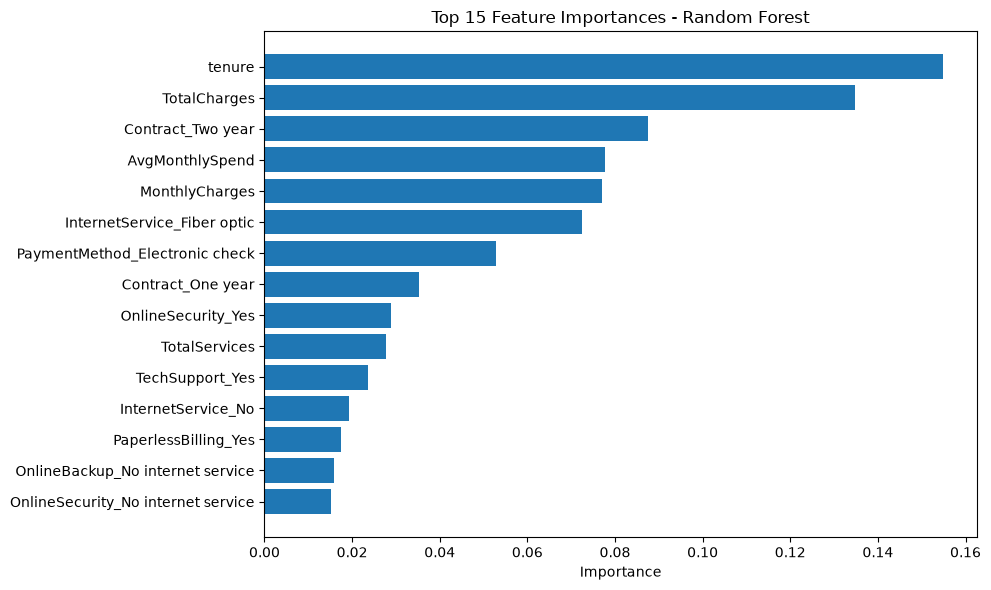

In [26]:
import matplotlib.pyplot as plt

top_features = importances.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Gradient Boosting feature importance

In [27]:
gb_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb_best.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 15 Gradient Boosting Feature Importances:")
print(gb_importances.head(15))

Top 15 Gradient Boosting Feature Importances:
                               feature  importance
27                   Contract_Two year    0.255037
1                               tenure    0.199797
26                   Contract_One year    0.138053
12         InternetService_Fiber optic    0.132151
30      PaymentMethod_Electronic check    0.049076
3                         TotalCharges    0.046916
25                 StreamingMovies_Yes    0.023326
5                      AvgMonthlySpend    0.018683
28                PaperlessBilling_Yes    0.015863
15                  OnlineSecurity_Yes    0.013665
2                       MonthlyCharges    0.013351
14  OnlineSecurity_No internet service    0.012085
13                  InternetService_No    0.011737
22     StreamingTV_No internet service    0.010676
16    OnlineBackup_No internet service    0.008652


## **Part 4 – Save the Best Model**
### Evaluate all tuned models on the test set

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tuned_models = {
    "Decision Tree": dt_best,
    "Random Forest": rf_best,
    "SVM": svm_best,
    "Gradient Boosting": gb_best
}

results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Churn)": precision_score(y_test, y_pred),
        "Recall (Churn)": recall_score(y_test, y_pred),
        "F1 (Churn)": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1 (Churn)", ascending=False)
print(results_df)

               Model  Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)
1      Random Forest  0.761533           0.535055        0.775401    0.633188
3  Gradient Boosting  0.743080           0.510169        0.804813    0.624481
2                SVM  0.739532           0.505942        0.796791    0.618899
0      Decision Tree  0.769340           0.566038        0.561497    0.563758


Cross-validation (Part 3) told us which model performs best on average across folds of the training data. Before picking a final model, we need to confirm that performance holds on the untouched test set — the real, final check. We'll compare all 4 tuned models side by side using accuracy, precision, recall, and F1 for the churn class (class 1), since that's what matters most for this problem.

### Save the best model with Joblib and Pickle

In [ ]:
import joblib
import pickle

# Save with Joblib
joblib.dump(rf_best, "best_churn_model.joblib")

# Save with Pickle
with open("best_churn_model.pkl", "wb") as f:
    pickle.dump(rf_best, f)

joblib.dump(scaler, "scaler.joblib")
joblib.dump(list(X_train.columns), "model_columns.joblib")

print("Model, scaler, and columns saved successfully.")

Model, scaler, and columns saved successfully.


We save the trained model object to disk so it can be reloaded later without retraining — required for both the task and for building the Streamlit app later. We save with both joblib (recommended for sklearn models, handles large numpy arrays efficiently) and pickle (as required by the task). We also save the scaler and the list of training columns, since we'll need to preprocess new input data identically at prediction time.